# Qwen3.5-0.8B — Zero-shot vs. LoRA Fine-tuned Product Classification




In [ ]:
!nvidia-smi

In [1]:

#CONFIG
N_PER_CLASS   = 724
TEST_SIZE     = 1000
TRAIN_EPOCHS  = 1
MODEL_NAME    = "Qwen/Qwen3.5-0.8B"
MAX_LEN       = 512
SEED          = 42


## 1. Install packages

In [2]:
!pip install -U "transformers>=4.57" accelerate peft trl datasets scikit-learn pandas matplotlib seaborn psycopg2-binary

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Suc

In [ ]:
!nvidia-smi

## 2. Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/shopping_assistant_qwen_lora"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs/qwen3.5-0.8b-main-category-lora"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(PROJECT_DIR)


Mounted at /content/drive
/content/drive/MyDrive/shopping_assistant_qwen_lora


## 3. Connect to the shared DB

In [4]:
import os
os.environ["DB_HOST"] = "134.122.33.127"
os.environ["DB_PORT"] = "5432"
os.environ["DB_NAME"] = "amazon_products"
os.environ["DB_USER"] = "amazon_user"
os.environ["DB_PASSWORD"] = "Mevisw7St5XExL?rlz9T"


In [5]:
import psycopg2

def get_connection():
    return psycopg2.connect(
        host=os.environ["DB_HOST"],
        port=os.environ["DB_PORT"],
        dbname=os.environ["DB_NAME"],
        user=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"],
    )

conn = get_connection()
cur = conn.cursor()
cur.execute("SELECT 1;")
print(cur.fetchone())
cur.close()
conn.close()


(1,)


In [6]:
import pandas as pd
SAMPLE_SQL = """
WITH ranked AS (
    SELECT
        title,
        main_category,
        ROW_NUMBER() OVER (PARTITION BY main_category ORDER BY RANDOM()) AS rn
    FROM amazon_products
    WHERE title IS NOT NULL
      AND main_category IS NOT NULL
      AND TRIM(title) <> ''
)
SELECT title, main_category
FROM ranked
WHERE rn <= %s;
"""

conn = get_connection()
df_raw = pd.read_sql(SAMPLE_SQL, conn, params=(N_PER_CLASS,))
conn.close()

print(df_raw.shape)
print(df_raw["main_category"].value_counts())


/tmp/ipykernel_2920/527896770.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(SAMPLE_SQL, conn, params=(N_PER_CLASS,))


(10999, 2)
main_category
Arts, Crafts & Party Supplies    724
Automotive                       724
Baby Products                    724
Beauty & Personal Care           724
Electronics & Computers          724
Fashion, Shoes & Luggage         724
Health & Household               724
Home & Kitchen                   724
Industrial & Scientific          724
Pet Supplies                     724
Smart Home                       724
Sports & Outdoors                724
Tools & Home Improvement         724
Toys & Games                     724
Video Games                      724
Gift Cards                       139
Name: count, dtype: int64


## 4.train/test splits

In [7]:
from datasets import Dataset

INSTRUCTION = "Classify the product into one main category."

records = [
    {
        "instruction": INSTRUCTION,
        "input": f"Title: {row.title}",
        "output": row.main_category,
    }
    for row in df_raw.itertuples()
]

full_dataset = Dataset.from_list(records)

dataset = full_dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

dataset["train"] = dataset["train"].shuffle(seed=SEED)

label_list = sorted(set(full_dataset["output"]))
allowed_labels = set(label_list)
print(dataset)
print("Number of labels:", len(label_list))
print(label_list)


DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 9999
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1000
    })
})
Number of labels: 16
['Arts, Crafts & Party Supplies', 'Automotive', 'Baby Products', 'Beauty & Personal Care', 'Electronics & Computers', 'Fashion, Shoes & Luggage', 'Gift Cards', 'Health & Household', 'Home & Kitchen', 'Industrial & Scientific', 'Pet Supplies', 'Smart Home', 'Sports & Outdoors', 'Tools & Home Improvement', 'Toys & Games', 'Video Games']


## 5. Load tokenizer + model

In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    dtype=torch.float16,
    trust_remote_code=True,
)
model.config.use_cache = True


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 1.75GB            

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

## 6. Zero-shot evaluation

In [9]:
import re

def clean_label(text):
    text = text.strip()
    text = text.split("\n")[0].strip()
    text = re.sub(r"^[\"'\s]+|[\"'\s]+$", "", text)
    text = text.replace("Answer:", "").strip()
    return text


def predict_category_zero_shot(title, model_, tokenizer_):
    labels_text = "\n".join(f"- {l}" for l in label_list)
    system_msg = (
        "You are a product classification assistant. "
        "Classify the product into exactly one category from the allowed label list. "
        "Output only the label text, nothing else."
    )
    user_msg = f"Allowed labels:\n{labels_text}\n\nProduct title:\n{title}"

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]
    prompt = tokenizer_.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer_(prompt, return_tensors="pt").to(model_.device)

    with torch.no_grad():
        outputs = model_.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=tokenizer_.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer_.decode(generated, skip_special_tokens=True)
    return response
# quick test
print(predict_category_zero_shot("Apple AirPods Pro Wireless Earbuds with Active Noise Cancellation", model, tokenizer))
print(predict_category_zero_shot("CeraVe Moisturizing Cream for Dry Skin", model, tokenizer))


Audio & Electronics

Beauty & Personal Care



In [10]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, classification_report, confusion_matrix
)
from tqdm.auto import tqdm

y_true_zs, y_pred_zs = [], []

for ex in tqdm(dataset["test"], desc="Zero-shot eval"):
    title = ex["input"].replace("Title:", "").strip()
    true_label = ex["output"].strip()

    raw_output_zs = predict_category_zero_shot(title, model, tokenizer)
    pred_label = clean_label(raw_output_zs)

    y_true_zs.append(true_label)
    y_pred_zs.append(pred_label)

acc_zs = accuracy_score(y_true_zs, y_pred_zs)
macro_f1_zs = f1_score(y_true_zs, y_pred_zs, average="macro")
weighted_f1_zs = f1_score(y_true_zs, y_pred_zs, average="weighted")
macro_prec_zs = precision_score(y_true_zs, y_pred_zs, average="macro", zero_division=0)
macro_rec_zs = recall_score(y_true_zs, y_pred_zs, average="macro", zero_division=0)
bal_acc_zs = balanced_accuracy_score(y_true_zs, y_pred_zs)
compliance_zs = sum(p in allowed_labels for p in y_pred_zs) / len(y_pred_zs)

print("Accuracy:", acc_zs)
print("Macro F1:", macro_f1_zs)
print("Weighted F1:", weighted_f1_zs)
print("Macro Precision:", macro_prec_zs)
print("Macro Recall:", macro_rec_zs)
print("Balanced Accuracy:", bal_acc_zs)
print("Exact Label Compliance Rate (cleaned):", compliance_zs)
print(classification_report(y_true_zs, y_pred_zs, labels=label_list, zero_division=0))

Zero-shot eval:   0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy: 0.311
Macro F1: 0.17939293141609688
Weighted F1: 0.29778121921927336
Macro Precision: 0.30265643754238136
Macro Recall: 0.19249702344153954
Balanced Accuracy: 0.3368697910226942
Exact Label Compliance Rate (cleaned): 0.943
                               precision    recall  f1-score   support

Arts, Crafts & Party Supplies       0.00      0.00      0.00        54
                   Automotive       0.50      0.02      0.03        66
                Baby Products       0.79      0.34      0.48        67
       Beauty & Personal Care       0.80      0.36      0.50        66
      Electronics & Computers       0.45      0.09      0.15        56
     Fashion, Shoes & Luggage       0.67      0.45      0.54        64
                   Gift Cards       0.64      1.00      0.78        14
           Health & Household       0.46      0.56      0.50        82
               Home & Kitchen       0.17      0.62      0.26        66
      Industrial & Scientific       0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


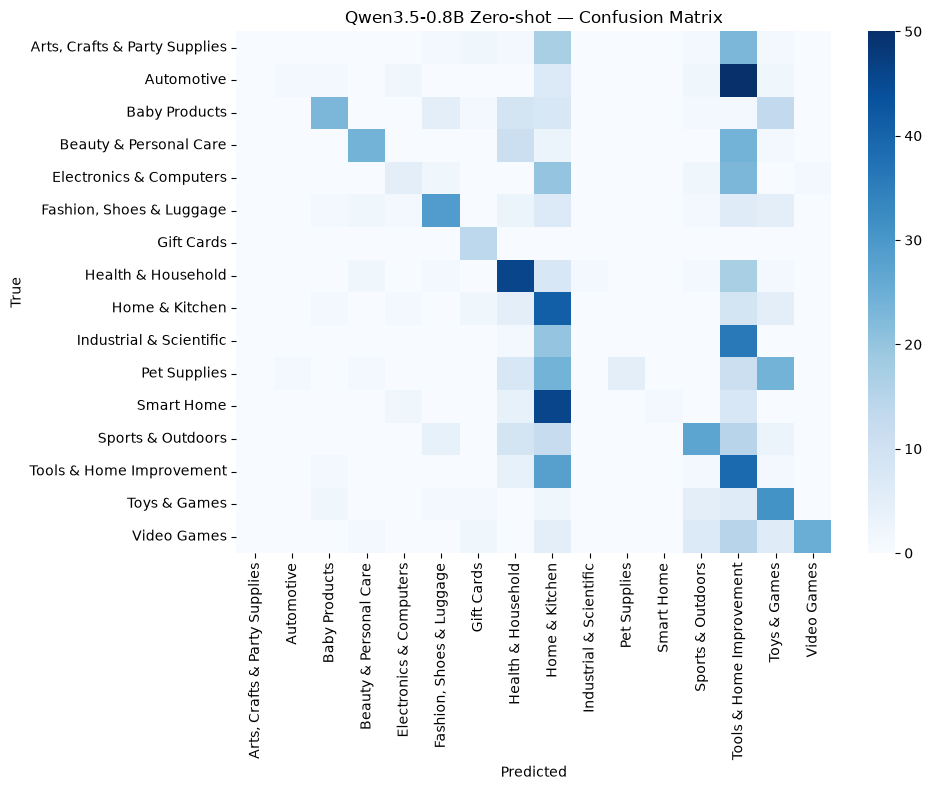

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues", annot=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(y_true_zs, y_pred_zs, label_list, "Qwen3.5-0.8B Zero-shot — Confusion Matrix")


## 7. LoRA fine-tune

In [12]:
def format_example(example):
    messages = [
        {"role": "system", "content": "You are a product classification assistant. Classify the product into exactly one main category. Output only the category label."},
        {"role": "user", "content": f"{example['instruction']}\n{example['input']}"},
        {"role": "assistant", "content": example["output"]},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

dataset = dataset.map(format_example)
print(dataset["train"][0]["text"])


Map:   0%|          | 0/9999 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

<|im_start|>system
You are a product classification assistant. Classify the product into exactly one main category. Output only the category label.<|im_end|>
<|im_start|>user
Classify the product into one main category.
Title: Nike J Soccer Shin Guards<|im_end|>
<|im_start|>assistant
<think>

</think>

Sports & Outdoors<|im_end|>



In [13]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

In [14]:
!pip install --upgrade torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [15]:
model.config.use_cache = False

from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,
    num_train_epochs=TRAIN_EPOCHS,

    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,

    fp16=True,
    optim="adamw_torch",
    report_to="none",
    gradient_checkpointing=False,

    dataset_text_field="text",
    max_length=MAX_LEN,
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    peft_config=lora_config,
    processing_class=tokenizer,
)

trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)


Adding EOS to train dataset:   0%|          | 0/9999 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/9999 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/9999 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/9999 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/9999 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,1.476542,1.465322,1.431064,147796.000000,0.743165
200,1.434562,1.440283,1.414878,296556.000000,0.746209
300,1.440084,1.422454,1.462374,444764.000000,0.748095
400,1.404730,1.407569,1.430331,592409.000000,0.749653
500,1.405430,1.397933,1.417754,739795.000000,0.751421
600,1.412880,1.391543,1.418291,888635.000000,0.752068
625,1.397430,1.391080,1.410601,925302.000000,0.752281


('/content/drive/MyDrive/shopping_assistant_qwen_lora/outputs/qwen3.5-0.8b-main-category-lora/tokenizer_config.json',
 '/content/drive/MyDrive/shopping_assistant_qwen_lora/outputs/qwen3.5-0.8b-main-category-lora/chat_template.jinja',
 '/content/drive/MyDrive/shopping_assistant_qwen_lora/outputs/qwen3.5-0.8b-main-category-lora/tokenizer.json')

## 8. Fine-tuned evaluation

In [16]:
model.config.use_cache = True

def predict_category_finetuned(title, model_, tokenizer_):
    messages = [
        {"role": "system", "content": "You are a product classification assistant. Classify the product into exactly one main category. Output only the category label."},
        {"role": "user", "content": f"Classify the product into one main category.\nTitle: {title}"},
    ]
    prompt = tokenizer_.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_(prompt, return_tensors="pt").to(model_.device)

    with torch.no_grad():
        outputs = model_.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=tokenizer_.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer_.decode(generated, skip_special_tokens=True)


y_true_ft, y_pred_ft = [], []

for ex in tqdm(dataset["test"], desc="Fine-tuned eval"):
    title = ex["input"].replace("Title:", "").strip()
    true_label = ex["output"].strip()

    raw_output_ft = predict_category_finetuned(title, model, tokenizer)
    pred_label = clean_label(raw_output_ft)

    y_true_ft.append(true_label)
    y_pred_ft.append(pred_label)

acc_ft = accuracy_score(y_true_ft, y_pred_ft)
macro_f1_ft = f1_score(y_true_ft, y_pred_ft, average="macro")
weighted_f1_ft = f1_score(y_true_ft, y_pred_ft, average="weighted")
macro_prec_ft = precision_score(y_true_ft, y_pred_ft, average="macro", zero_division=0)
macro_rec_ft = recall_score(y_true_ft, y_pred_ft, average="macro", zero_division=0)
bal_acc_ft = balanced_accuracy_score(y_true_ft, y_pred_ft)
compliance_ft = sum(p in allowed_labels for p in y_pred_ft) / len(y_pred_ft)

print("Accuracy:", acc_ft)
print("Macro F1:", macro_f1_ft)
print("Weighted F1:", weighted_f1_ft)
print("Macro Precision:", macro_prec_ft)
print("Macro Recall:", macro_rec_ft)
print("Balanced Accuracy:", bal_acc_ft)
print("Exact Label Compliance Rate (cleaned):", compliance_ft)
print(classification_report(y_true_ft, y_pred_ft, labels=label_list, zero_division=0))


Fine-tuned eval:   0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy: 0.765
Macro F1: 0.7746068779998205
Weighted F1: 0.7610370679829667
Macro Precision: 0.7736216409012707
Macro Recall: 0.7815488271312627
Balanced Accuracy: 0.7815488271312627
Exact Label Compliance Rate (cleaned): 1.0
                               precision    recall  f1-score   support

Arts, Crafts & Party Supplies       0.76      0.81      0.79        54
                   Automotive       0.78      0.74      0.76        66
                Baby Products       0.79      0.79      0.79        67
       Beauty & Personal Care       0.84      0.95      0.89        66
      Electronics & Computers       0.79      0.82      0.81        56
     Fashion, Shoes & Luggage       0.83      0.81      0.82        64
                   Gift Cards       1.00      1.00      1.00        14
           Health & Household       0.77      0.56      0.65        82
               Home & Kitchen       0.62      0.68      0.65        66
      Industrial & Scientific       0.63      0.60      0.61  

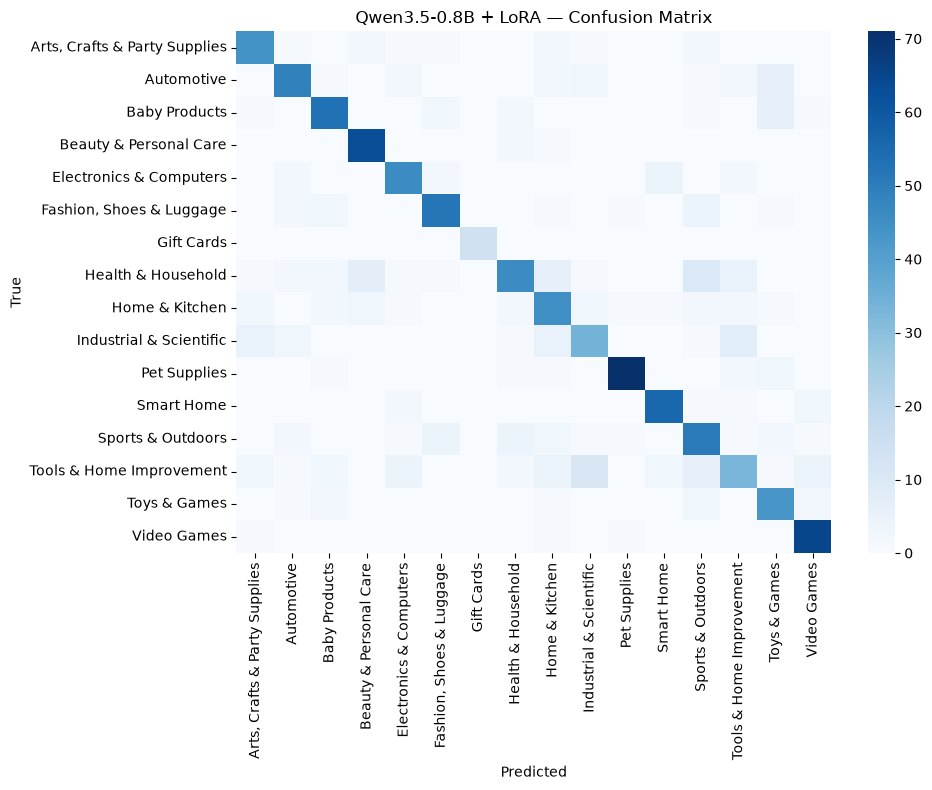

In [17]:
plot_confusion(y_true_ft, y_pred_ft, label_list, "Qwen3.5-0.8B + LoRA — Confusion Matrix")

## 9. Zero-shot vs. fine-tuned comparison

In [22]:
comparison_df = pd.DataFrame([
    {
        "Model": "Qwen3.5-0.8B Zero-shot",
        "Accuracy": acc_zs,
        "Macro F1": macro_f1_zs,
        "Weighted F1": weighted_f1_zs,
        "Macro Precision": macro_prec_zs,
        "Macro Recall": macro_rec_zs,
        "Balanced Accuracy": bal_acc_zs,
        "Exact Label Compliance Rate": compliance_zs,
    },
    {
        "Model": "Qwen3.5-0.8B + LoRA",
        "Accuracy": acc_ft,
        "Macro F1": macro_f1_ft,
        "Weighted F1": weighted_f1_ft,
        "Macro Precision": macro_prec_ft,
        "Macro Recall": macro_rec_ft,
        "Balanced Accuracy": bal_acc_ft,
        "Exact Label Compliance Rate": compliance_ft,
    },
])

display(comparison_df)

comparison_df.to_csv(f"{PROJECT_DIR}/qwen_lora_vs_zeroshot_results.csv", index=False)
print("Saved comparison results to:", f"{PROJECT_DIR}/qwen_lora_vs_zeroshot_results.csv")


,Model,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Balanced Accuracy,Exact Label Compliance Rate
0,Qwen3.5-0.8B Zero-shot,0.311,0.179393,0.297781,0.302656,0.192497,0.336870,0.943
1,Qwen3.5-0.8B + LoRA,0.765,0.774607,0.761037,0.773622,0.781549,0.781549,1.000


Saved comparison results to: /content/drive/MyDrive/shopping_assistant_qwen_lora/qwen_lora_vs_zeroshot_results.csv


### predictions outside the allowed label set

In [19]:
invalid_zs = sorted(set(y_pred_zs) - allowed_labels)
invalid_ft = sorted(set(y_pred_ft) - allowed_labels)

print("Invalid zero-shot labels:", len(invalid_zs), invalid_zs[:20])
print("Invalid fine-tuned labels:", len(invalid_ft), invalid_ft[:20])


Invalid zero-shot labels: 12 ['Art Deco Tiles', 'Art Painting', 'Art Supplies', 'Art, Crafts & Party Supplies', 'Artificial Aquarium Decoration', 'Audio', 'Audio MusicCast 20 Wireless Speaker', 'Gaming', 'Heated Cat House for Outdoor Cats in Winter', 'Need For Speed Carbon: Own The City (essentials) /psp', 'Not Found', 'Travelon Anti-theft Packable Backpack']
Invalid fine-tuned labels: 0 []
